Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted.


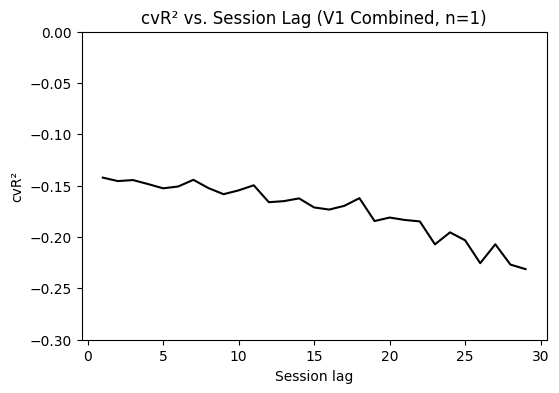

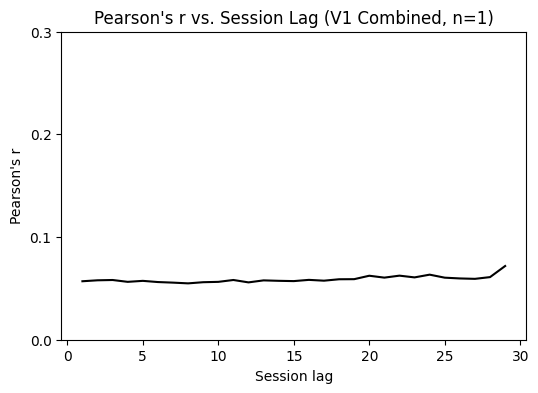

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)
print("Google Drive mounted.")

def plot_fig1_from_npz_combined_v1(
    isub_list=[1],  # For now just sub-1
    to_zscore=0,
    vreg=1,
    metrics=["r2split", "pearson_rori"]
):
    """
    Replicates fig1.m using combined V1 data (V1v + V1d).
    """
    zscore_str = ['', '_zscore', '_zeroMean', '_equalStd', '_zeroROImean'][to_zscore]
    root_folder = "/content/drive/My Drive/V1_Drift/repDrift_expand"

    for metric_key in metrics:
        all_lags = []

        for isub in isub_list:
            file_path = os.path.join(root_folder, f"regressSessCombineROI_sub{isub}{zscore_str}.npz")
            if not os.path.exists(file_path):
                print(f"[SKIP] File not found: {file_path}")
                continue

            data = np.load(file_path)
            key = f"v{vreg}_{metric_key}"  # <- combined V1 key
            if key not in data:
                print(f"[SKIP] Key not found: {key}")
                continue

            mat = data[key]  # shape: [nsess, nvox, nsess]
            if mat.ndim != 3:
                print(f"[SKIP] Matrix is not 3D: {key}")
                continue

            nsess = mat.shape[0]
            avg_mat = np.mean(mat, axis=1)  # shape: [nsess, nsess]

            # Compute lag-wise diagonal means
            lags = []
            for lag in range(1, nsess):
                diag_vals = np.diag(avg_mat, k=lag)
                lags.append(np.mean(diag_vals))
            all_lags.append(lags)

        if not all_lags:
            print(f"[ERROR] No valid data for metric: {metric_key}")
            continue

        all_lags = np.array(all_lags)  # [nsub, n_lags]
        mean_lags = np.mean(all_lags, axis=0)
        sem_lags = np.std(all_lags, axis=0) / np.sqrt(all_lags.shape[0])

        # Plot
        lag_axis = np.arange(1, len(mean_lags) + 1)
        plt.figure(figsize=(6, 4))
        plt.plot(lag_axis, mean_lags, label='Mean', color='black')
        plt.fill_between(lag_axis, mean_lags - sem_lags, mean_lags + sem_lags,
                         alpha=0.3, label='±1 SEM')
        plt.xlabel("Session lag")

        # Label and y-limits based on metric type
        if "r2" in metric_key:
            ylabel = "cvR²"
            plt.ylabel(ylabel)
            plt.ylim(-0.3, 0)
            plt.yticks(np.arange(-0.3, 0.01, 0.05))
        else:
            ylabel = "Pearson's r"
            plt.ylabel(ylabel)
            plt.ylim(0.0, 0.3)
            plt.yticks(np.arange(0.0, 0.31, 0.1))

        plt.title(f"{ylabel} vs. Session Lag (V1 Combined, n={all_lags.shape[0]})")


# Run for sub-1 for now (update to full list when ready)
plot_fig1_from_npz_combined_v1(
    isub_list=[1],
    to_zscore=0,
    vreg=1,
    metrics=["r2split", "pearson_rori"]
)


# new update figure 3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Subjects: [1, 2, 3]
[WARN] Missing spearman for subject 1
[WARN] Missing spearman for subject 2
Loaded 1 subjects | ns=30 | nperms=1000 | metric=spearman


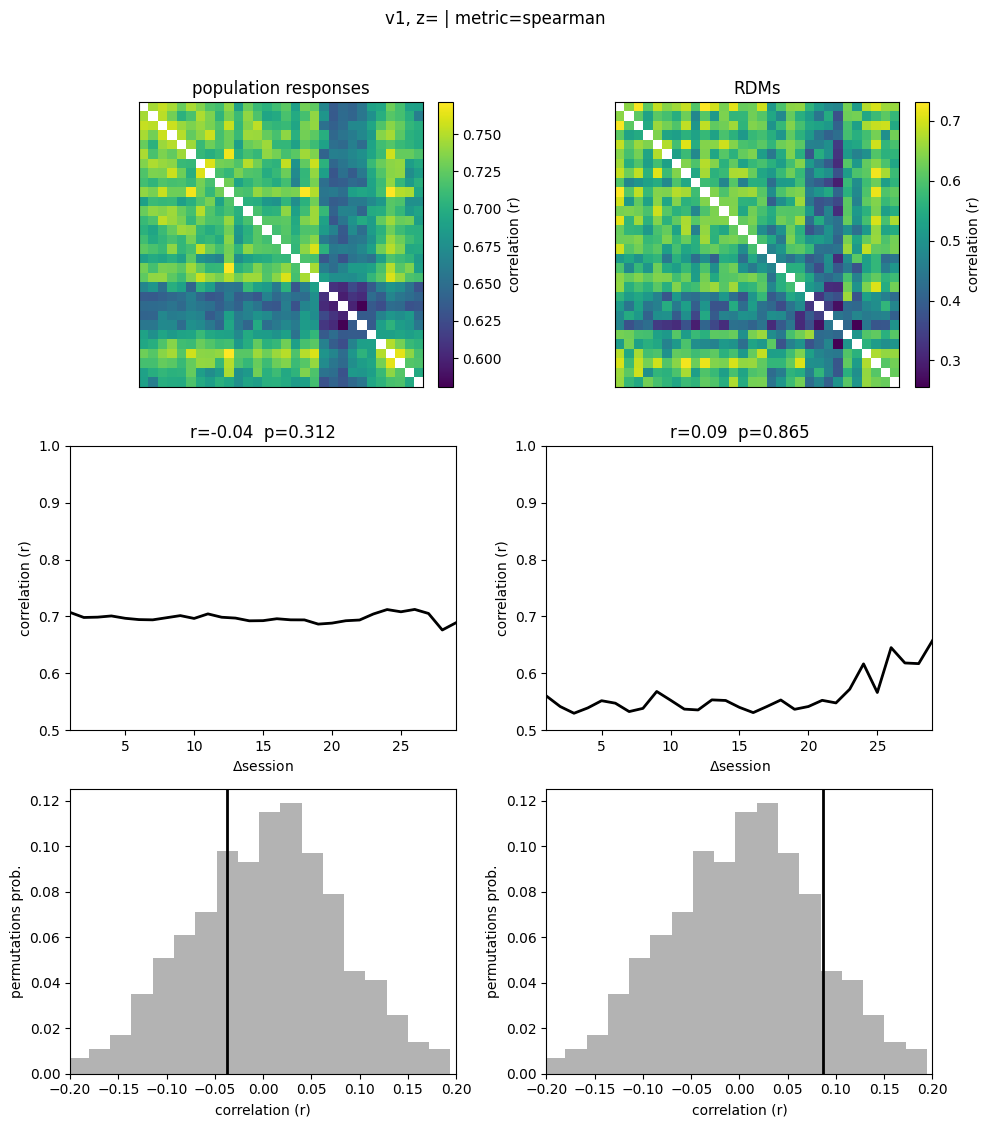

In [ ]:
# ===============================================================
# fig3_group_plot.py — Fig 3 (Population & RDM), coreyVersion=2
# Replicates Roth & Merriam (2023) Figure 3 using only Pearson metric
# ===============================================================

import os, re, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr
from google.colab import drive

# =========================
# CONFIG
# =========================
ROOT          = "/content/drive/My Drive/V1_Drift/repDrift_expand"
VREG          = 1
TO_ZSCORE     = 0
NPERMS_WANT   = 1000
FIXED_FIRST   = False
R2THRESH      = 0.0
SUBJECTS      = None       # None → auto-discover
METRIC_FILTER = "spearman"  # <<<<<< fixed for paper replication
ADD_COLORBARS = True
SINGLE_SUBJECT_LINES = True
HIST_BINS     = 20
LINE_WIDE     = 2
LINE_NARROW   = 1
HIST_XLIM     = (-0.2, 0.2)

# =========================
# Drive
# =========================
drive.mount('/content/drive', force_remount=False)

# =========================
# Helpers
# =========================
def _zstr(z):
    m = ['', '_zscore', '_zeroMean', '_equalStd', '_zeroROImean']
    return m[z] if 0 <= z < len(m) else ''

def _subroot(root, vreg, sub):
    return os.path.join(root, f"v{vreg}", f"Subject {sub}")

def _discover_subjects(root, vreg):
    vdir = os.path.join(root, f"v{vreg}")
    if not os.path.isdir(vdir):
        return []
    out = []
    for name in sorted(os.listdir(vdir)):
        m = re.match(r"Subject\s+(\d+)$", name)
        if m:
            out.append(int(m.group(1)))
    return out

def _safe_pearson(x, y):
    x = np.asarray(x, np.float64); y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.nan
    try:    return pearsonr(x[m], y[m])[0]
    except: return np.nan

def _corr_offdiag_vs_dist(mat, dist):
    mask = dist > 0
    return _safe_pearson(dist[mask], mat[mask])

def _ensure(a, kind):
    if kind == "mat" and a.ndim == 2: return a
    if kind == "perm_mat" and a.ndim == 3: return a
    raise ValueError(f"Unexpected shape {a.shape} for {kind}")

# =========================
# Load & stack group (Pearson only)
# =========================
def load_group(root, vreg, to_zscore, nperms_want, fixedFirst, r2thresh, subjects=None):
    if subjects is None:
        subjects = _discover_subjects(root, vreg)
    print(f"Subjects: {subjects}")
    if not subjects:
        raise RuntimeError("No subjects found.")

    zstr  = _zstr(to_zscore)
    ftag  = "_fixedFirst_" if fixedFirst else ""
    r2tag = "" if (r2thresh is None or r2thresh <= 0) else "_r2thresh"

    per_sub = []
    minNS = minNperms = None
    distRef = None

    for s in subjects:
        sub_dir = _subroot(root, vreg, s)
        target = f"permPop{ftag}N{NPERMS_WANT}_v{vreg}_sub{s}_{METRIC_FILTER}{zstr}{r2tag}.npz"
        fpath = os.path.join(sub_dir, target)
        if not os.path.exists(fpath):
            print(f"[WARN] Missing {METRIC_FILTER} for subject {s}")
            continue
        with np.load(fpath, allow_pickle=True) as D:
            ns = int(D["minSessions"])
            nperms = int(D["imgCorrMatOriPerm"].shape[0])
            dist   = np.array(D["distMatrix"])
        minNS = ns if minNS is None else min(minNS, ns)
        minNperms = nperms if minNperms is None else min(minNperms, nperms)
        if distRef is None: distRef = dist
        per_sub.append((s, fpath, nperms, ns))

    if not per_sub:
        raise RuntimeError(f"No subjects with {METRIC_FILTER} metric found.")

    ns = minNS
    nperms = min(minNperms, nperms_want)
    distMat = distRef[:ns, :ns]

    subj_ok = []
    A_stack, B_stack, Ap_stack, Bp_stack = [], [], [], []
    for s, fpath, nperms_sub, ns_sub in per_sub:
        with np.load(fpath, allow_pickle=True) as D:
            A  = _ensure(np.array(D["avgImgCorrMatOri"]), "mat")[:ns, :ns]
            B  = _ensure(np.array(D["betweenSessCorrOri"]), "mat")[:ns, :ns]
            Ap = _ensure(np.array(D["imgCorrMatOriPerm"]), "perm_mat")[:nperms, :ns, :ns]
            Bp = _ensure(np.array(D["betweenSessCorrOriPerm"]), "perm_mat")[:nperms, :ns, :ns]
        A_stack.append(A); B_stack.append(B)
        Ap_stack.append(Ap); Bp_stack.append(Bp)
        subj_ok.append(s)

    A_S  = np.stack(A_stack, axis=0)
    B_S  = np.stack(B_stack, axis=0)
    Ap_S = np.stack(Ap_stack, axis=0)
    Bp_S = np.stack(Bp_stack, axis=0)

    print(f"Loaded {len(subj_ok)} subjects | ns={ns} | nperms={nperms} | metric={METRIC_FILTER}")

    return dict(
        subjects=np.array(subj_ok, int),
        ns=ns, nperms=nperms, distMatrix=distMat, metric=METRIC_FILTER,
        avgImgCorrMatOri_S=A_S,
        betweenSessCorrOri_S=B_S,
        imgCorrMatOriPerm_S=Ap_S,
        betweenSessCorrOriPerm_S=Bp_S
    )

# =========================
# Plot
# =========================
def plot_fig3(agg):
    subjects   = agg["subjects"]
    ns         = agg["ns"]
    nperms     = agg["nperms"]
    distMatrix = agg["distMatrix"]

    A_S  = agg["avgImgCorrMatOri_S"]
    B_S  = agg["betweenSessCorrOri_S"]
    Ap_S = agg["imgCorrMatOriPerm_S"]
    Bp_S = agg["betweenSessCorrOriPerm_S"]

    val_label = "correlation (r)"
    lags = np.arange(1, ns)
    subLag_A = np.zeros((len(subjects), ns-1))
    subLag_B = np.zeros((len(subjects), ns-1))
    distCorr_obs, distCorr_perm, p_perm = np.zeros(2), np.zeros((2, nperms)), np.zeros(2)

    for col, (Smat, Pmat) in enumerate([(A_S, Ap_S), (B_S, Bp_S)]):
        sub_r = np.zeros(len(subjects))
        sub_r_perm = np.zeros((len(subjects), nperms))
        for si in range(len(subjects)):
            M = Smat[si]
            sub_r[si] = _corr_offdiag_vs_dist(M, distMatrix)
            for d in range(1, ns):
                if col == 0: subLag_A[si, d-1] = np.nanmean(M[distMatrix == d])
                else:        subLag_B[si, d-1] = np.nanmean(M[distMatrix == d])
            for ip in range(nperms):
                sub_r_perm[si, ip] = _corr_offdiag_vs_dist(Pmat[si, ip], distMatrix)
        distCorr_obs[col]  = np.nanmean(sub_r)
        distCorr_perm[col] = np.nanmean(sub_r_perm, axis=0)
        p_perm[col]        = 1 - np.sum(distCorr_perm[col] >= distCorr_obs[col]) / float(nperms)

    # plot
    fig, axes = plt.subplots(3, 2, figsize=(10, 11))
    titles = ["population responses", "RDMs"]
    mats = [A_S, B_S]

    for col in range(2):
        meanMat = np.nanmean(mats[col], axis=0)
        mask = np.abs(np.subtract.outer(np.arange(ns), np.arange(ns))) > 0
        masked = meanMat.copy(); masked[~mask] = np.nan
        ax = axes[0, col]
        im = ax.imshow(masked, origin="upper", cmap="viridis")
        finite = masked[np.isfinite(masked)]
        if finite.size: im.set_clim(finite.min(), finite.max())
        if ADD_COLORBARS:
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label(val_label)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.set_xlabel("session"); ax.set_ylabel("session")
        ax.set_title(titles[col])

        # Δ-session curves
        ax2 = axes[1, col]
        curves = subLag_A if col == 0 else subLag_B
        if SINGLE_SUBJECT_LINES:
            for si in range(curves.shape[0]):
                ax2.plot(lags, curves[si], linewidth=LINE_NARROW, alpha=0.7)
        ax2.plot(lags, np.nanmean(curves, axis=0), 'k', lw=LINE_WIDE)
        ax2.set_xlim(1, ns-1); ax2.set_ylim(0.5, 1.0)
        ax2.set_xlabel(r'$\Delta$session'); ax2.set_ylabel(val_label)
        ax2.set_title(f"r={distCorr_obs[col]:.2f}  p={p_perm[col]:.3f}")

        # permutation histogram
        ax3 = axes[2, col]
        counts, bins = np.histogram(distCorr_perm[col], bins=HIST_BINS)
        probs = counts / max(counts.sum(), 1)
        ax3.bar(bins[:-1], probs, width=np.diff(bins),
                align='edge', color=[0.7]*3, edgecolor='none')
        ax3.axvline(distCorr_obs[col], color='k', lw=LINE_WIDE)
        ax3.set_xlim(*HIST_XLIM)
        ax3.set_xlabel('correlation (r)'); ax3.set_ylabel('permutations prob.')

    plt.suptitle(f"v{VREG}, z={_zstr(TO_ZSCORE)} | metric={METRIC_FILTER}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

# =========================
# Run
# =========================
agg = load_group(ROOT, VREG, TO_ZSCORE, NPERMS_WANT, FIXED_FIRST, R2THRESH, SUBJECTS)
plot_fig3(agg)


# plot 1 update

Mounted at /content/drive
Loaded: /content/drive/MyDrive/V1_Drift/repDrift_expand/perm1000.pkl
Keys: ['toNormalize', 'toZscore', 'useMedian', 'r2thresh', 'nrois', 'rois', 'permOrders', 'subSessions', 'subjects', 'minSessions'] ...
subjects: [3]
minSessions: 30 nsubjects: 1
r2oriSplit shape: (1, 30, 30)
pearsonRori shape: (1, 30, 30)
r2oriPerm shape: (1, 1000, 30, 30)


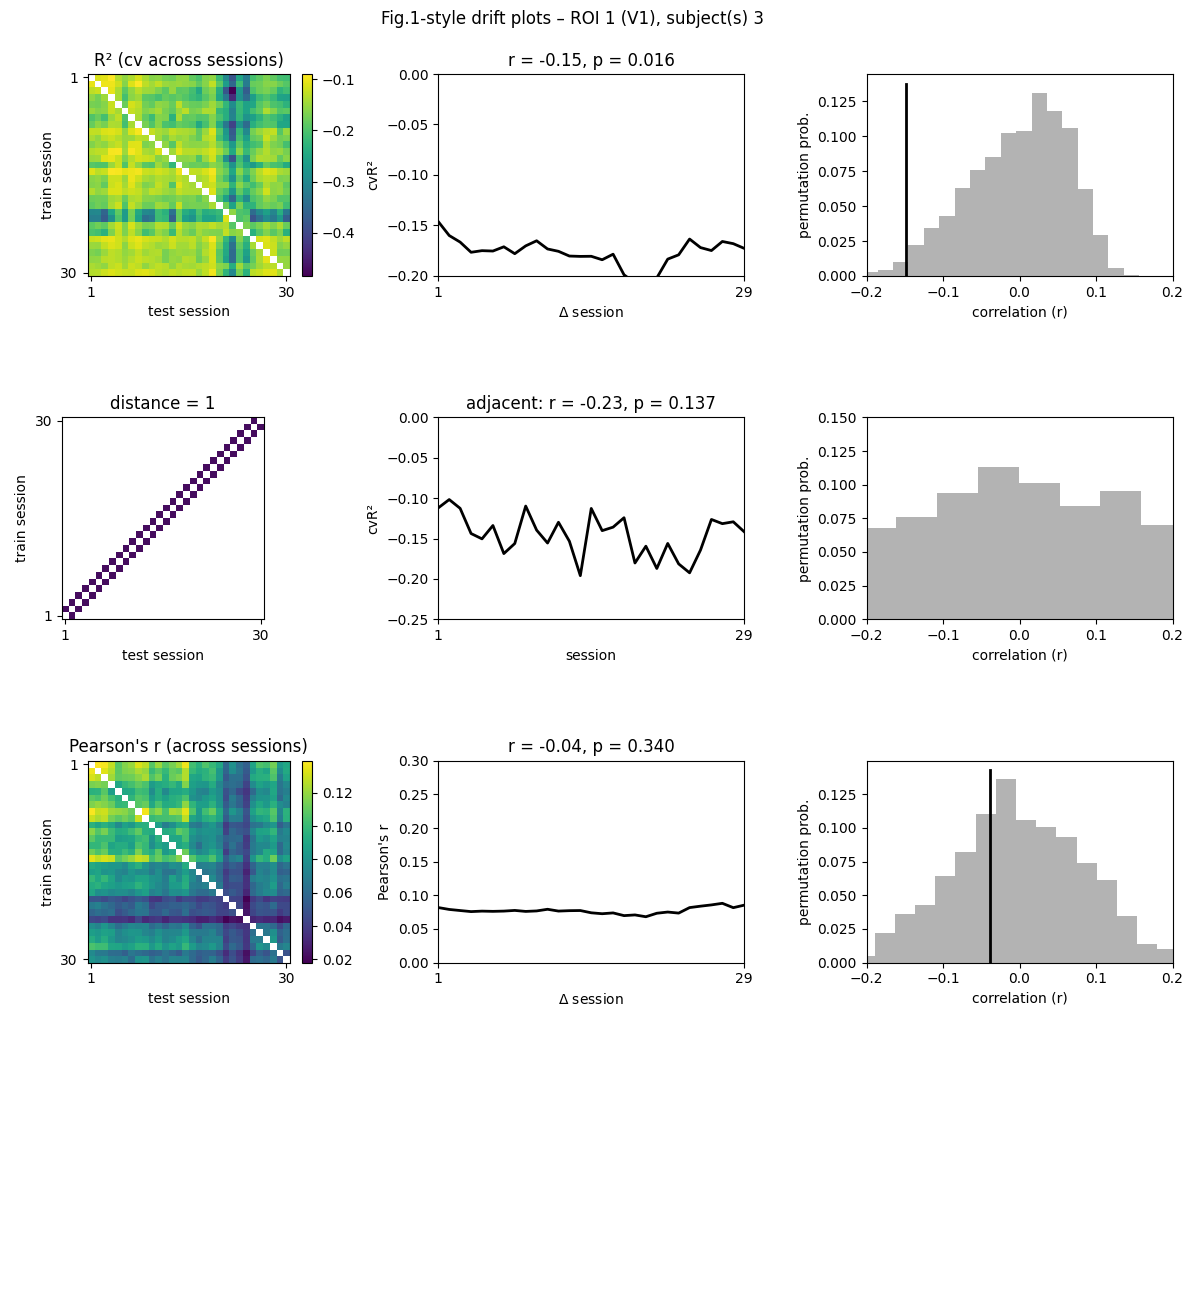

In [25]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --------------------------------------------------------
# 1. Load permutation result file
# --------------------------------------------------------
SAVE_DIR = "/content/drive/MyDrive/V1_Drift/repDrift_expand"

# <<< EDIT THIS IF NEEDED >>>
PERM_FILE = os.path.join(SAVE_DIR, "perm1000.pkl")  # or "perm10.pkl"

with open(PERM_FILE, "rb") as f:
    perm = pickle.load(f)

print("Loaded:", PERM_FILE)
print("Keys:", list(perm.keys())[:10], "...")

# --------------------------------------------------------
# 2. Pull out variables we need (ROI 1, single subject)
# --------------------------------------------------------
subjects      = perm["subjects"]         # e.g. [3]
subSessions   = perm["subSessions"]      # shape (nsubjects, nsessions)
minSessions   = int(perm["minSessions"]) # 30 in your save_perms_expand
nrois         = perm["nrois"]
nsubjects     = len(subjects)

print("subjects:", subjects)
print("minSessions:", minSessions, "nsubjects:", nsubjects)

# ROI indexing: MATLAB rois = 1..4 -> Python idx 0..3
iroi = 1      # V1
roi_idx = iroi - 1

# core data (lists length = nrois; each entry per ROI)
r2oriSplit       = perm["r2oriSplit"][roi_idx]       # (nsubjects, nsessions, nsessions)
pearsonRori      = perm["pearsonRori"][roi_idx]      # (nsubjects, nsessions, nsessions)
r2oriPerm        = perm["r2oriPerm"][roi_idx]        # (nsubjects, nperms, nsessions, nsessions)
pearsonOriPerm   = perm["pearsonOriPerm"][roi_idx]   # (nsubjects, nperms, nsessions, nsessions)

# distance-based summaries (we'll mostly use shapes / lengths)
r2OriDist        = perm["r2OriDist"][roi_idx]        # (nsubjects, nsessions-1)
pearsonOriDist   = perm["pearsonOriDist"][roi_idx]   # (nsubjects, nsessions-1)

# sanity
print("r2oriSplit shape:", r2oriSplit.shape)
print("pearsonRori shape:", pearsonRori.shape)
print("r2oriPerm shape:", r2oriPerm.shape)

# --------------------------------------------------------
# 3. Basic setup (session distance matrix)
# --------------------------------------------------------
# Use only first minSessions sessions for everything
sess = np.arange(minSessions)  # 0..minSessions-1 (index; correlation invariant to shift)
sessDiff = sess[:, None] - sess[None, :]                 # like sess - sess'
sessDistVec = np.abs(sessDiff)                           # distance matrix |i-j|

# We'll treat single-subject case (like singleSubject=1)
SINGLE_SUBJECT = True
nperms = r2oriPerm.shape[1]

# colors and plotting params (roughly matching MATLAB)
histBins = 20
linewidthWide = 2
linewidthNarrow = 1
surfaceAlpha = 0.1

# one color for the subject, and gray for histogram
sub_color = np.array([0.0, 0.4470, 0.7410])
face_color = np.array([0.7, 0.7, 0.7])

# --------------------------------------------------------
# 4. Helper: correlation ignoring NaNs
# --------------------------------------------------------
def safe_corr(x, y):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 3:
        return np.nan
    r, _ = pearsonr(x[mask], y[mask])
    return r

# --------------------------------------------------------
# 5. Compute things for coreyVersion = 2
#    (per subject correlation, then average)
# --------------------------------------------------------
# We'll store everything in a dict keyed by metric name: "r2" / "pearson"
results = {}

for metric_name, similarityData_full, similarityPerm_full in [
    ("r2",      r2oriSplit,     r2oriPerm),
    ("pearson", pearsonRori,    pearsonOriPerm),
]:
    # restrict to first minSessions
    similarityData = similarityData_full[:, :minSessions, :minSessions]       # (nsub, S, S)
    similarityPerm = similarityPerm_full[:, :, :minSessions, :minSessions]    # (nsub, nperms, S, S)

    # distance correlation per subject
    subDistCorr = np.zeros((nsubjects,), dtype=float)
    subDistCorrPerm = np.zeros((nsubjects, nperms), dtype=float)

    # curves per subject: mean similarity vs Δsession
    subMeanDistData = np.zeros((nsubjects, minSessions - 1), dtype=float)

    for si in range(nsubjects):
        subData = similarityData[si]  # (S, S)
        # vectorize all off-diagonal entries
        mask_off = sessDistVec > 0
        dists_vec = sessDistVec[mask_off]
        vals_vec = subData[mask_off]

        # real correlation for this subject
        subDistCorr[si] = safe_corr(dists_vec, vals_vec)

        # mean similarity vs Δsession
        for d in range(1, minSessions):
            subMeanDistData[si, d - 1] = np.nanmean(subData[sessDistVec == d])

        # permutations for this subject
        permMat = similarityPerm[si]  # (nperms, S, S)
        for ip in range(nperms):
            tempPerm = permMat[ip]
            permVals = tempPerm[mask_off]
            subDistCorrPerm[si, ip] = safe_corr(dists_vec, permVals)

    # mean across subjects (here just 1 subject)
    distCorr = np.nanmean(subDistCorr)
    distCorrPerm = np.nanmean(subDistCorrPerm, axis=0)  # (nperms,)
    pPermDistCorr = np.mean(distCorrPerm <= distCorr)

    # also store mean curve vs Δsession across subjects
    meanDistCurve = np.nanmean(subMeanDistData, axis=0)

    # ----- Adjacent (distance=1) analysis -----
    idist = 1
    mask_adj = (sessDistVec == idist)
    train_idx, test_idx = np.where(mask_adj)
    # "train session" indices (MATLAB uses 1..S, but correlation is affine-invariant)
    trainSess = train_idx.astype(float)

    subDistSessCorr = np.zeros((nsubjects,), dtype=float)
    subDistSessCorrPerm = np.zeros((nsubjects, nperms), dtype=float)
    subMeanDistSessData = np.zeros((nsubjects, minSessions - 1), dtype=float)

    for si in range(nsubjects):
        subData = similarityData[si]
        dataDistSess = subData[mask_adj]  # all pairs at distance 1
        subDistSessCorr[si] = safe_corr(trainSess, dataDistSess)

        # mean similarity per "train session" index
        for first_idx in range(minSessions - 1):
            subMeanDistSessData[si, first_idx] = np.nanmean(
                dataDistSess[train_idx == first_idx]
            )

        permMat = similarityPerm[si]  # (nperms, S, S)
        for ip in range(nperms):
            tempPerm = permMat[ip]
            permDistVec = tempPerm[mask_adj]
            subDistSessCorrPerm[si, ip] = safe_corr(trainSess, permDistVec)

    distSessCorr = np.nanmean(subDistSessCorr)
    distSessCorrPerm = np.nanmean(subDistSessCorrPerm, axis=0)  # (nperms,)
    pPermDistSessCorr = np.mean(distSessCorrPerm <= distSessCorr)

    meanAdjCurve = np.nanmean(subMeanDistSessData, axis=0)

    results[metric_name] = {
        "similarityData": similarityData,
        "similarityPerm": similarityPerm,
        "distCorr": distCorr,
        "distCorrPerm": distCorrPerm,
        "pPermDistCorr": pPermDistCorr,
        "meanDistCurve": meanDistCurve,
        "distSessCorr": distSessCorr,
        "distSessCorrPerm": distSessCorrPerm,
        "pPermDistSessCorr": pPermDistSessCorr,
        "meanAdjCurve": meanAdjCurve,
    }

# --------------------------------------------------------
# 6. Plotting: reproduce the Fig. 1 layout
# --------------------------------------------------------
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
plt.subplots_adjust(wspace=0.4, hspace=0.7)
plt.set_cmap("viridis")   # or "turbo" to be closer to MATLAB

# convenient alias
def ax_rc(r, c):
    return axes[r, c]

# Helper to plot similarity matrix (mean over subjects)
def plot_similarity_matrix(ax, simData, title, ylabel, metric):
    # simData: (nsub, S, S)
    temp = np.nanmean(simData, axis=0)  # mean across subjects

    # ---------------------------------------------------
    # Fixed value limits (match the article exactly!)
    # ---------------------------------------------------
    if metric == "r2":
        vmin, vmax = -0.2, -0.15
    elif metric == "pearson":
        vmin, vmax = 0.1, 0.35
    else:
        raise ValueError("metric must be 'r2' or 'pearson'")

    # mask diagonal from color range
    off_mask = sessDistVec > 0
    vmin = np.nanmin(temp[off_mask])
    vmax = np.nanmax(temp[off_mask])

    # hide diagonal visually
    temp_plot = temp.copy()
    np.fill_diagonal(temp_plot, np.nan)

    # draw heatmap
    im = ax.imshow(temp_plot, origin="lower", vmin=vmin, vmax=vmax)

    # flip y-axis so session 1 is at top
    ax.invert_yaxis()

    # labels
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("test session")
    ax.set_ylabel("train session")

    ax.set_xticks([0, minSessions - 1])
    ax.set_xticklabels([1, minSessions])
    ax.set_yticks([0, minSessions - 1])
    ax.set_yticklabels([1, minSessions])

    # ---- Add colorbar ----
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# Helper: distance curve + subject lines
def plot_dist_curve(ax, meanCurve, metric_name, results_dict):
    distCorr = results_dict["distCorr"]
    pPerm = results_dict["pPermDistCorr"]
    d = np.arange(1, minSessions)  # Δsession

    # Plot curve (single subject case)
    ax.plot(d, meanCurve, "-", color="k", linewidth=linewidthWide)

    # X-axis
    ax.set_xlabel(r"$\Delta$ session")
    ax.set_xlim(1, len(d))
    ax.set_xticks([1, len(d)])
    ax.set_xticklabels([1, len(d)])

    # ----- Y-axis limits depending on metric -----
    if metric_name == "r2":
        ax.set_ylim(-0.20, 0.00)
        ax.set_ylabel("cvR²")
    else:  # Pearson
        ax.set_ylim(0.00, 0.30)
        ax.set_ylabel("Pearson's r")

    # Title: correlation + p-value
    ax.set_title(f"r = {distCorr:0.2f}, p = {pPerm:0.3f}")


# Helper: permutation histogram for distance correlation
def plot_perm_hist(ax, distCorr, distCorrPerm):
    # ----- Compute histogram as PROBABILITY -----
    counts, bins = np.histogram(distCorrPerm, bins=histBins)
    prob = counts / counts.sum()    # convert to real probability

    ax.bar(
        bins[:-1],
        prob,
        width=np.diff(bins),
        align="edge",
        color=face_color,
        edgecolor="none"
    )

    # Mark empirical r
    yl = ax.get_ylim()
    ax.plot([distCorr, distCorr], [yl[0], yl[1]], "k-", linewidth=linewidthWide)

    # axis limits
    ax.set_xlim(-0.2, 0.2)
    if abs(distCorr) > 0.2:
        ax.set_xlim(-0.3, 0.3)

    ax.set_xlabel("correlation (r)")
    ax.set_ylabel("permutation prob.")


# Helper: adjacent schematic
def plot_adjacent_schematic(ax):
    adj_mask = (np.abs(sessDiff) == 1).astype(float)
    im = ax.imshow(np.abs(sessDiff), origin="lower", alpha=adj_mask)
    ax.set_xlabel("test session")
    ax.set_ylabel("train session")
    ax.set_xticks([0, minSessions - 1])
    ax.set_xticklabels([1, minSessions])
    ax.set_yticks([0, minSessions - 1])
    ax.set_yticklabels([1, minSessions])
    ax.set_title("distance = 1")
    ax.set_aspect("equal")

# Helper: adjacent generalization curve
def plot_adjacent_curve(ax, meanAdjCurve, metric_name, results_dict):
    distSessCorr = results_dict["distSessCorr"]
    pPerm = results_dict["pPermDistSessCorr"]
    x = np.arange(1, minSessions)  # first session index
    ax.plot(x, meanAdjCurve, "-", color="k", linewidth=linewidthWide)
    ax.set_xlim(1, len(x))
    ax.set_ylim(-0.25, 0)
    ax.set_xticks([1, len(x)])
    ax.set_xticklabels([1, len(x)])
    if metric_name == "r2":
        ax.set_ylabel("cvR²")
    else:
        ax.set_ylabel("Pearson's r")
    ax.set_xlabel("session")
    ax.set_title(f"adjacent: r = {distSessCorr:0.2f}, p = {pPerm:0.3f}")
    #ax.set_aspect("equal", adjustable="box")

# Helper: adjacent permutation histogram
def plot_adjacent_perm_hist(ax, distSessCorr, distSessCorrPerm):
    # ----- Compute histogram as TRUE probability -----
    counts, bins = np.histogram(distSessCorrPerm, bins=histBins)
    prob = counts / counts.sum()  # convert bins to probabilities

    ax.bar(
        bins[:-1],           # bin left edges
        prob,                # probability per bin
        width=np.diff(bins), # bin widths
        align="edge",
        color=face_color,
        edgecolor="none"
    )

    # vertical empirical marker
    yl = ax.get_ylim()
    ax.plot([distSessCorr, distSessCorr], [yl[0], yl[1]], "k-", linewidth=linewidthWide)

    # x range identical to Fig. 1
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylim(0, 0.15)

    ax.set_xlabel("correlation (r)")
    ax.set_ylabel("permutation prob.")


# --------------------------------------------------------
# 7. Fill the subplots
# Layout mapping (MATLAB indices -> (row,col)):
#   1  2  3
#   4  5  6
#   7  8  9
#  10 11 12
#
# For R² (metric i=1):
#   1: similarity matrix
#   2: distance curve
#   3: perm histogram
#   4: adjacent schematic
#   5: adjacent distance curve
#   6: adjacent perm histogram
#
# For Pearson (metric i=2):
#   7: similarity matrix
#   8: distance curve
#   9: perm histogram
# --------------------------------------------------------

# --- R² panels (top two rows) ---
r2_res = results["r2"]
plot_similarity_matrix(ax_rc(0, 0), r2_res["similarityData"], "R² (cv across sessions)", "train session", metric="r2")
plot_dist_curve(ax_rc(0, 1), r2_res["meanDistCurve"], "r2", r2_res)
plot_perm_hist(ax_rc(0, 2), r2_res["distCorr"], r2_res["distCorrPerm"])

plot_adjacent_schematic(ax_rc(1, 0))
plot_adjacent_curve(ax_rc(1, 1), r2_res["meanAdjCurve"], "r2", r2_res)
plot_adjacent_perm_hist(ax_rc(1, 2), r2_res["distSessCorr"], r2_res["distSessCorrPerm"])

# --- Pearson panels (3rd row) ---
pearson_res = results["pearson"]
plot_similarity_matrix(ax_rc(2, 0), pearson_res["similarityData"], "Pearson's r (across sessions)", "train session",metric="pearson")
plot_dist_curve(ax_rc(2, 1), pearson_res["meanDistCurve"], "pearson", pearson_res)
plot_perm_hist(ax_rc(2, 2), pearson_res["distCorr"], pearson_res["distCorrPerm"])

# Hide the last row (unused, for now)
for c in range(3):
    ax_rc(3, c).axis("off")

plt.suptitle("Fig.1-style drift plots – ROI 1 (V1), subject(s) " + ", ".join(map(str, subjects)), y=0.92)
plt.show()


In [ ]:
# ================= Alignment Audit =================
import os, re, numpy as np, h5py, scipy.io as sio
from google.colab import drive
drive.mount('/content/drive', force_remount=False)


ROOT = "/content/drive/My Drive/V1_Drift/repDrift_expand"
PRF  = "/content/drive/My Drive/V1_Drift/prfsample_expand"
NSD  = "/content/drive/MyDrive/V1_Drift/NSD/nsddata/experiments/nsd/nsd_expdesign.mat"

def _zstr(z): return ['', '_zscore', '_zeroMean', '_equalStd', '_zeroROImean'][z]

def audit_alignment(isub:int, vreg:int=1, to_zscore:int=0, verbose=True):
    z = _zstr(to_zscore)
    subdir = os.path.join(ROOT, f"v{vreg}", f"Subject {isub}")
    comb_npz = os.path.join(subdir, f"regressSessCombineROI_sub{isub}{z}.npz")
    sim_npz  = os.path.join(subdir, f"simPopResp_v{vreg}_sub{isub}{z}.npz")
    prf_h5   = os.path.join(PRF,    f"prfSampleStim_v{vreg}_sub{isub}.h5")

    out = {"subject": isub, "vreg": vreg, "z": z, "ok": True, "notes": []}

    # --- existence
    for p in [NSD, comb_npz, sim_npz, prf_h5]:
        if not os.path.exists(p):
            out["ok"] = False; out["notes"].append(f"❌ Missing file: {p}")
    if not out["ok"]:
        return out

    # --- NSD design → expected allImgs (exactly how your prf code builds it)
    M = sio.loadmat(NSD)
    subjectim = M["subjectim"]                   # [8, ntrials]
    masterordering = M["masterordering"].ravel() - 1
    valid = masterordering[masterordering < subjectim.shape[1]]
    expected_allImgs = np.unique(subjectim[isub-1, valid]).astype(np.int32)

    # --- Read pRF H5 metadata
    with h5py.File(prf_h5, "r") as f:
        if "allImgs" not in f:
            out["ok"] = False; out["notes"].append("❌ prf H5 missing dataset 'allImgs'")
            return out
        h5_allImgs = f["allImgs"][:].astype(np.int32)
        rois = f["rois"][:] if "rois" in f else np.array([], dtype=np.int32)
        nL   = int(f.attrs.get("numLevels", -1))
        nO   = int(f.attrs.get("numOrientations", -1))

        # voxel counts per ROI from H5
        h5_vox_per_roi = {}
        for r in rois:
            k = f"prfSampleLev/roi_{r}"
            if k in f:
                h5_vox_per_roi[int(r)] = f[k].shape[1]
            else:
                out["notes"].append(f"⚠️ H5 missing dataset {k}")

    # --- Compare allImgs (IDs and order)
    if h5_allImgs.shape != expected_allImgs.shape or not np.all(h5_allImgs == expected_allImgs):
        out["ok"] = False
        # compute differences
        set_h5 = set(h5_allImgs.tolist()); set_exp = set(expected_allImgs.tolist())
        only_h5 = sorted(list(set_h5 - set_exp))[:10]
        only_exp = sorted(list(set_exp - set_h5))[:10]
        first_ord_mismatch = next((i for i,(a,b) in enumerate(zip(h5_allImgs, expected_allImgs)) if a!=b), None)
        out["notes"].append(
            "❌ allImgs mismatch between NSD design and prf H5:"
            f"\n   - length H5={len(h5_allImgs)} vs expected={len(expected_allImgs)}"
            f"\n   - first order mismatch index: {first_ord_mismatch}"
            f"\n   - in H5 not in expected (first 10): {only_h5}"
            f"\n   - in expected not in H5 (first 10): {only_exp}"
        )
    else:
        out["notes"].append(f"✅ allImgs match exactly (n={len(h5_allImgs)})")

    # --- Load regression-combine NPZ: sessions & ROI voxel counts
    C = np.load(comb_npz, allow_pickle=True)
    nsplits = int(np.array(C["nsplits"]).item()) if "nsplits" in C else None
    # ROI pRF info is stored as dict per ROI inside 'allRoiPrf'
    allRoiPrf = (C["allRoiPrf"].item() if "allRoiPrf" in C else {})
    # infer voxel counts from regression coef tensors
    reg_vox_counts = {}
    for key in C.files:
        if re.match(rf"v{vreg}_vox_coef$", key):
            reg_vox_counts["lev"] = C[key].shape[1]    # (nsess, nvox, L+3)
        if re.match(rf"v{vreg}_vox_ori_coef$", key):
            reg_vox_counts["ori"] = C[key].shape[1]    # (nsess, nvox, L*O+3)
            nsess_reg = C[key].shape[0]

    # session check: nsess should be nsplits-1 (mean split excluded)
    if nsplits is None or "ori" not in reg_vox_counts:
        out["ok"] = False; out["notes"].append("❌ Missing nsplits or vox_ori_coef in regression NPZ")
    else:
        if nsess_reg != nsplits - 1:
            out["ok"] = False
            out["notes"].append(f"❌ Session count mismatch: coef nsess={nsess_reg} vs nsplits-1={nsplits-1}")
        else:
            out["notes"].append(f"✅ Sessions consistent: nsess={nsess_reg} (= nsplits-1)")

    # ROI voxel-count check: H5 vs regression vs allRoiPrf
    if vreg < 4:
        roi_list = [0,1]         # V1v+V1d  (mirrors your code)
    else:
        roi_list = [0]

    vox_h5 = sum(h5_vox_per_roi.get(r, 0) for r in roi_list)
    vox_reg = reg_vox_counts.get("ori", None)

    vox_allRoiPrf = 0
    for r in roi_list:
        if r+1 in allRoiPrf and "r2" in allRoiPrf[r+1]:
            vox_allRoiPrf += int(np.array(allRoiPrf[r+1]["r2"]).size)

    if vox_reg is None:
        out["ok"] = False; out["notes"].append("❌ Could not infer nvox from regression NPZ")
    else:
        msgs = []
        if vox_h5 != vox_reg:
            out["ok"] = False; msgs.append(f"H5 nvox={vox_h5} vs regression nvox={vox_reg}")
        if vox_allRoiPrf and vox_allRoiPrf != vox_reg:
            out["ok"] = False; msgs.append(f"allRoiPrf nvox={vox_allRoiPrf} vs regression nvox={vox_reg}")
        if msgs:
            out["notes"].append("❌ Voxel count mismatch: " + " | ".join(msgs))
        else:
            out["notes"].append(f"✅ Voxel counts align: nvox={vox_reg}")

    # --- Simulated population file must index H5 images correctly
    S = np.load(sim_npz, allow_pickle=True)
    simImgs = S["simImgs"].astype(int)          # 1..N indices into H5 allImgs
    nimgs   = int(simImgs.size)
    try:
        V1 = S["voxSessResp"].shape   # (nvox, nsess, nimg)
        V2 = S["voxSessRespOri"].shape
    except Exception:
        out["ok"] = False; out["notes"].append("❌ Missing voxSessResp* arrays in simPopResp npz")
        return out

    if not (simImgs.min()==1 and simImgs.max()==nimgs and np.all(np.diff(simImgs)==1)):
        out["ok"] = False
        out["notes"].append(f"❌ simImgs not 1..N contiguous: min={simImgs.min()} max={simImgs.max()} len={nimgs}")
    else:
        out["notes"].append(f"✅ simImgs index 1..{nimgs} (contiguous)")

    if nimgs != len(h5_allImgs):
        out["ok"] = False
        out["notes"].append(f"❌ simPop nimgs={nimgs} but H5 allImgs={len(h5_allImgs)}")
    else:
        out["notes"].append(f"✅ simPop nimgs matches H5 (n={nimgs})")

    # --- Level / orientation dimension sanity
    if nL > 0 and nO > 0:
        # expected coef widths: L+2 extras + 1 const ;  L*O + 2 extras + 1 const
        # We don't know the exact width from file names here; just sanity print:
        out["notes"].append(f"ℹ️ H5 attrs: numLevels={nL}, numOrientations={nO}")

    if verbose:
        print(f"\n=== Alignment audit: sub {isub} | v{vreg} | z='{z}' ===")
        for line in out["notes"]: print(line)
        print("Overall:", "✅ OK" if out["ok"] else "❌ MISMATCHES FOUND")
    return out

# ---- run it ----
_ = audit_alignment(isub=3, vreg=1, to_zscore=0)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Alignment audit: sub 3 | v1 | z='' ===
✅ allImgs match exactly (n=10000)
❌ Session count mismatch: coef nsess=31 vs nsplits-1=30
✅ Voxel counts align: nvox=1254
✅ simImgs index 1..100 (contiguous)
❌ simPop nimgs=100 but H5 allImgs=10000
ℹ️ H5 attrs: numLevels=7, numOrientations=8
Overall: ❌ MISMATCHES FOUND
